<a href="https://colab.research.google.com/github/reller26/signal_and_image_proc_final_project/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Face Diffusion Prior for OOD Restoration — DDRM vs PnP-DPIR vs Hybrid
Training-free image restoration comparing a **face-trained diffusion prior (DDRM)**, a **general-purpose
denoiser (PnP-DPIR / DRUNet)**, and a **hybrid** that uses the diffusion prior at high noise and the
general denoiser below a crossover \(\sigma_c\). Tasks: super-resolution, deblurring, inpainting.
Domains: faces (in-distribution), satellite, general natural images (OOD).

**Run order:** enable **T4 GPU** (Runtime → Change runtime type), then run every cell top to bottom.

Methods: **M1** PnP-DPIR · **M2** DDRM (face prior) · **M3** DDRM early-stop · **M4** hybrid (sweeps \(\sigma_c\)).

In [1]:
# ====================================================================
# 0. Environment
# ====================================================================
!nvidia-smi

Thu Oct  8 11:45:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
RESULTS_DIR = '/content/drive/MyDrive/final_project/results'
IMAGES_DIR  = '/content/drive/MyDrive/final_project/images'
os.makedirs(RESULTS_DIR, exist_ok=True); os.makedirs(IMAGES_DIR, exist_ok=True)
print('results ->', RESULTS_DIR)

Mounted at /content/drive
results -> /content/drive/MyDrive/final_project/results


In [3]:
%cd /content
![ -d ddrm ] || git clone https://github.com/bahjat-kawar/ddrm.git
![ -d DPIR ] || git clone https://github.com/cszn/DPIR.git
!pip -q install lpips gdown scikit-image pyyaml datasets
print('repos + deps ready')

/content
Cloning into 'ddrm'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 83 (delta 28), reused 21 (delta 21), pack-reused 38 (from 1)
Receiving objects: 100% (83/83), 3.20 MiB | 8.05 MiB/s, done.
Resolving deltas: 100% (29/29), done.
Cloning into 'DPIR'...
remote: Enumerating objects: 239, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 239 (delta 48), reused 35 (delta 35), pack-reused 179 (from 1)
Receiving objects: 100% (239/239), 6.85 MiB | 21.06 MiB/s, done.
Resolving deltas: 100% (104/104), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.2 MB/s eta 0:00:00
repos + deps ready


In [4]:
# Checkpoints: DRUNet denoiser + CelebA-HQ face diffusion model (from a live HF mirror).
import os
os.makedirs('/content/DPIR/model_zoo', exist_ok=True)
os.makedirs('/content/ddrm/exp/logs/celeba', exist_ok=True)
!rm -f /content/DPIR/model_zoo/drunet_color.pth
!wget -c -O /content/DPIR/model_zoo/drunet_color.pth "https://github.com/cszn/KAIR/releases/download/v1.0/drunet_color.pth"
!rm -f /content/ddrm/exp/logs/celeba/celeba_hq.ckpt
!wget -c -O /content/ddrm/exp/logs/celeba/celeba_hq.ckpt "https://huggingface.co/gwang-kim/DiffusionCLIP-CelebA_HQ/resolve/main/celeba_hq.ckpt?download=true"
for p,mn in [('/content/DPIR/model_zoo/drunet_color.pth',100),('/content/ddrm/exp/logs/celeba/celeba_hq.ckpt',400)]:
    mb=os.path.getsize(p)/1e6; print(f'{os.path.basename(p)}: {mb:.1f} MB'); assert mb>mn, f'{p} too small - download failed'
print('checkpoints OK')

--2026-10-08 11:48:15--  https://github.com/cszn/KAIR/releases/download/v1.0/drunet_color.pth
Resolving github.com (github.com)... 20.29.134.23
Connecting to github.com (github.com)|20.29.134.23|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/228241233/f963c6d5-a527-4171-9c96-003b2a2f4006?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-10-08T12%3A21%3A36Z&rscd=attachment%3B+filename%3Ddrunet_color.pth&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-10-08T11%3A20%3A51Z&ske=2026-10-08T12%3A21%3A36Z&sks=b&skv=2018-11-09&sig=kdgNUO9Sljv8o2e4CWrQ0Qkafu7y5PJiawQ5DybpvCM%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc5MTQ2MzY5NSwibmJmIjoxNzkxNDYwMDk1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUu

In [5]:
# ====================================================================
# 1. Configuration
# ====================================================================
import torch, numpy as np, random, os, glob
from PIL import Image
device = 'cuda' if torch.cuda.is_available() else 'cpu'
assert device=='cuda', 'Enable the T4 GPU first (Runtime -> Change runtime type -> T4).'

SIZE, C   = 256, 3
N_IMAGES  = 15
NOISE_STD = 0.01         # measurement noise std in [0,1]
STEPS     = 20           # DDRM sampling steps
ETA, ETAB = 0.85, 1.0
SIGMA_C_GRID = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]   # hybrid crossover sweep
T_STOP    = 300          # M3 early-stop timestep (0..999)
INPAINT_MODE = 'random'  # 'random' (scattered) | 'box' (one large hole)
INPAINT_FRAC = 0.5       # fraction missing, for 'random'
INPAINT_BOX  = 96        # central hole side (px), for 'box'
SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
# NOTE: task/dataset are NOT global here. The engine (run_all/run_matrix/save_qualitative) takes them as
# arguments; the single-image demo (Section 7) sets its own `demo_task`/`demo_dataset`.
print('device', device)

device cuda


In [6]:
# ====================================================================
# 2. Datasets (auto-download) + image IO
# ====================================================================
def list_images(dataset):
    folder = os.path.join(IMAGES_DIR, dataset); os.makedirs(folder, exist_ok=True)
    files = sorted(sum([glob.glob(os.path.join(folder, e)) for e in ('*.png','*.jpg','*.jpeg')], []))
    return files[:N_IMAGES]
def load_img(path, size=SIZE):
    im = Image.open(path).convert('RGB').resize((size, size), Image.BICUBIC)
    return (torch.from_numpy(np.array(im)).float().permute(2,0,1)[None]/255.).to(device)
def save_img(x, path):
    a = x.clamp(0,1)[0].permute(1,2,0).cpu().numpy()
    Image.fromarray((a*255).round().astype('uint8')).save(path)

def fetch_faces(n=N_IMAGES):          # CelebA-HQ 256 (in-distribution), streamed from HF
    from datasets import load_dataset
    out = os.path.join(IMAGES_DIR,'faces'); os.makedirs(out, exist_ok=True)
    ds = load_dataset("korexyz/celeba-hq-256x256", split="train", streaming=True); i=0
    for ex in ds:
        img = next((v for v in ex.values() if isinstance(v, Image.Image)), None)
        if img is None: continue
        img.convert('RGB').resize((SIZE,SIZE)).save(os.path.join(out,f'face_{i:03d}.png')); i+=1
        if i>=n: break
    print('faces:', len(os.listdir(out)))

def fetch_satellite(n=N_IMAGES):      # EuroSAT (OOD, RGB), auto-download
    from torchvision.datasets import EuroSAT
    out = os.path.join(IMAGES_DIR,'satellite'); os.makedirs(out, exist_ok=True)
    ds = EuroSAT(root='/content/eurosat', download=True)
    for i in range(n): ds[i][0].resize((SIZE,SIZE), Image.BICUBIC).save(os.path.join(out,f'sat_{i:03d}.png'))
    print('satellite:', len(os.listdir(out)))

def fetch_general(n=N_IMAGES):        # Kodak natural images (OOD, textured)
    import urllib.request, ssl
    out = os.path.join(IMAGES_DIR,'general'); os.makedirs(out, exist_ok=True)
    ctx = ssl.create_default_context(); ctx.check_hostname=False; ctx.verify_mode=ssl.CERT_NONE
    got=0
    for k in range(1,25):
        if got>=n: break
        try:
            with urllib.request.urlopen(f"https://r0k.us/graphics/kodak/kodak/kodim{k:02d}.png", context=ctx, timeout=30) as r, \
                 open(os.path.join(out,f'kodim{k:02d}.png'),'wb') as f: f.write(r.read())
            got+=1
        except Exception as e: print('skip',k,e)
    print('general:', len(os.listdir(out)))

# populate any empty domain
if not list_images('faces'):     fetch_faces()
if not list_images('satellite'): fetch_satellite()
if not list_images('general'):   fetch_general()
print({d: len(list_images(d)) for d in ('faces','satellite','general')})

{'faces': 15, 'satellite': 15, 'general': 15}


In [7]:
# ====================================================================
# 3. Metrics + logging (PSNR / SSIM / LPIPS)
# ====================================================================
import lpips, pandas as pd, datetime
from skimage.metrics import peak_signal_noise_ratio as _psnr, structural_similarity as _ssim
_lpips = lpips.LPIPS(net='alex').to(device); [p.requires_grad_(False) for p in _lpips.parameters()]
def _np(x): return x.clamp(0,1)[0].permute(1,2,0).cpu().numpy()
def calc_psnr(est,gt): return float(_psnr(_np(gt),_np(est),data_range=1.0))
def calc_ssim(est,gt): return float(_ssim(_np(gt),_np(est),channel_axis=2,data_range=1.0))
def calc_lpips(est,gt):
    with torch.no_grad(): return float(_lpips(est*2-1, gt*2-1).item())
def all_metrics(est,gt): return dict(psnr=calc_psnr(est,gt), ssim=calc_ssim(est,gt), lpips=calc_lpips(est,gt))
CSV = os.path.join(RESULTS_DIR,'metrics.csv')
def log_result(method, dataset, task, img, m, **extra):
    row = dict(time=datetime.datetime.now().isoformat(timespec='seconds'), method=method, dataset=dataset,
               task=task, image=img, noise=NOISE_STD, steps=STEPS, **m, **extra)
    pd.DataFrame([row]).to_csv(CSV, mode='a', header=not os.path.exists(CSV), index=False)
print('logging to', CSV)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 181MB/s]


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth
logging to /content/drive/MyDrive/final_project/results/metrics.csv


In [8]:
# ====================================================================
# 4. Load models
# DDRM's diffusion UNet and DPIR's DRUNet both ship a package named models; we import each with a small
# sys.path / sys.modules dance.
# ====================================================================
import sys, yaml, argparse
DDRM, DPIR = '/content/ddrm', '/content/DPIR'
def _fresh_models(repo):
    for m in [k for k in list(sys.modules) if k=='models' or k.startswith('models.')]: del sys.modules[m]
    for p in (DDRM,DPIR):
        while p in sys.path: sys.path.remove(p)
    sys.path.insert(0, repo)

# --- DDRM diffusion UNet + SVD operators ---
_fresh_models(DDRM)
from models.diffusion import Model as DDRMModel
sys.path.insert(0, DDRM)
from functions.svd_replacement import SuperResolution, Deblurring, Inpainting
def dict2namespace(d):
    ns=argparse.Namespace()
    for k,v in d.items(): setattr(ns,k,dict2namespace(v) if isinstance(v,dict) else v)
    return ns
with open(os.path.join(DDRM,'configs/celeba_hq.yml')) as f: ddrm_cfg=dict2namespace(yaml.safe_load(f))
ddrm_model = DDRMModel(ddrm_cfg).to(device).eval()
ddrm_model.load_state_dict(torch.load('/content/ddrm/exp/logs/celeba/celeba_hq.ckpt', map_location=device))
for p in ddrm_model.parameters(): p.requires_grad_(False)
print('DDRM face model loaded')

# --- DPIR DRUNet denoiser ---
_fresh_models(DPIR)
from models.network_unet import UNetRes
drunet = UNetRes(in_nc=4,out_nc=3,nc=[64,128,256,512],nb=4,act_mode='R',
                 downsample_mode='strideconv',upsample_mode='convtranspose').to(device).eval()
drunet.load_state_dict(torch.load('/content/DPIR/model_zoo/drunet_color.pth', map_location=device), strict=True)
for p in drunet.parameters(): p.requires_grad_(False)
print('DRUNet loaded')

# --- betas + transforms ([-1,1]) ---
num_timesteps = 1000
betas = torch.from_numpy(np.linspace(1e-4, 2e-2, num_timesteps)).float().to(device)
def data_transform(x): return 2*x - 1.0
def inverse_data_transform(x): return torch.clamp((x+1.0)/2.0, 0.0, 1.0)
def drunet_x0(x_pm1, sigma_ve):
    s01 = float(min(max(float(sigma_ve)/2.0, 0.0), 0.196))
    nmap = torch.full((x_pm1.shape[0],1,x_pm1.shape[2],x_pm1.shape[3]), s01, device=x_pm1.device)
    with torch.no_grad(): out01 = drunet(torch.cat([((x_pm1+1)/2).clamp(0,1), nmap], dim=1))
    return out01*2 - 1

DDRM face model loaded
DRUNet loaded


In [9]:
# ====================================================================
# 5. Samplers (DDRM + hybrid) and the closed-form data step
# ====================================================================
def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0)
    return (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)

def guided_steps(x, seq, model, b, H_funcs, y_0, sigma_0, etaB, etaA, etaC, ext_denoise=None, sigma_c=0.0):
    """DDRM's reverse process; denoiser swappable to `ext_denoise` for sigma<=sigma_c (the hybrid)."""
    with torch.no_grad():
        singulars = H_funcs.singulars()
        Sigma = torch.zeros(x.shape[1]*x.shape[2]*x.shape[3], device=x.device); Sigma[:singulars.shape[0]] = singulars
        U_t_y = H_funcs.Ut(y_0); Sig_inv_U_t_y = U_t_y / singulars[:U_t_y.shape[-1]]
        largest_alphas = compute_alpha(b, (torch.ones(x.size(0)) * seq[-1]).to(x.device).long())
        largest_sigmas = (1 - largest_alphas).sqrt() / largest_alphas.sqrt()
        large_singulars_index = torch.where(singulars * largest_sigmas[0,0,0,0] > sigma_0)
        inv_sz = torch.zeros(x.shape[1]*x.shape[2]*x.shape[3]).to(singulars.device)
        inv_sz[large_singulars_index] = sigma_0 / singulars[large_singulars_index]; inv_sz = inv_sz.view(1,-1)
        init_y = torch.zeros(x.shape[0], x.shape[1]*x.shape[2]*x.shape[3]).to(x.device)
        init_y[:, large_singulars_index[0]] = U_t_y[:, large_singulars_index[0]] / singulars[large_singulars_index].view(1,-1)
        init_y = init_y.view(*x.size())
        rem = (largest_sigmas.view(-1,1)**2 - inv_sz**2).view(x.shape[0],x.shape[1],x.shape[2],x.shape[3]).clamp_min(0.0).sqrt()
        init_y = (init_y + rem * x) / largest_sigmas
        x = H_funcs.V(init_y.view(x.size(0), -1)).view(*x.size())
        n = x.size(0); seq_next = [-1] + list(seq[:-1]); x0_preds=[]; xs=[x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t=(torch.ones(n)*i).to(x.device); next_t=(torch.ones(n)*j).to(x.device)
            at=compute_alpha(b,t.long()); at_next=compute_alpha(b,next_t.long()); xt=xs[-1].to(x.device)
            sigma=(1-at).sqrt()[0,0,0,0]/at.sqrt()[0,0,0,0]
            if (ext_denoise is not None) and (float(sigma)<=float(sigma_c)):
                x0_t = ext_denoise(xt/at.sqrt()[0,0,0,0], sigma); et=(xt-at.sqrt()*x0_t)/(1-at).sqrt()
            else:
                et=model(xt,t)
                if et.size(1)==6: et=et[:,:3]
                x0_t=(xt-et*(1-at).sqrt())/at.sqrt()
            sigma_next=(1-at_next).sqrt()[0,0,0,0]/at_next.sqrt()[0,0,0,0]
            V_t_x0=H_funcs.Vt(x0_t); SVt_x0=(V_t_x0*Sigma)[:,:U_t_y.shape[1]]
            falses=torch.zeros(V_t_x0.shape[1]-singulars.shape[0],dtype=torch.bool,device=xt.device)
            cbl=singulars*sigma_next>sigma_0; cal=singulars*sigma_next<sigma_0
            cb=torch.hstack((cbl,falses)); ca=torch.hstack((cal,falses))
            stdC=sigma_next*etaC; stC=torch.sqrt(sigma_next**2-stdC**2)
            stdA=sigma_next*etaA; stA=torch.sqrt(sigma_next**2-stdA**2)
            dB=torch.sqrt(sigma_next**2-sigma_0**2/singulars[cbl]**2*(etaB**2))
            Vn=V_t_x0+stC*H_funcs.Vt(et)+stdC*torch.randn_like(V_t_x0)
            Vn[:,ca]=V_t_x0[:,ca]+stA*((U_t_y-SVt_x0)/sigma_0)[:,cal]+stdA*torch.randn_like(V_t_x0[:,ca])
            Vn[:,cb]=Sig_inv_U_t_y[:,cbl]*etaB+(1-etaB)*V_t_x0[:,cb]+dB*torch.randn_like(U_t_y)[:,cbl]
            xt_next=(at_next.sqrt()[0,0,0,0]*H_funcs.V(Vn)).view(*x.shape)
            x0_preds.append(x0_t.to('cpu')); xs.append(xt_next.to('cpu'))
    return xs, x0_preds

def ddrm_sample(y0, Hf, sigma_c=0.0, ext=False, t_stop=None, seed=0):
    torch.manual_seed(seed); xT=torch.randn(1,C,SIZE,SIZE,device=device)
    seq=list(range(0,num_timesteps,num_timesteps//STEPS)); ret_x0=False
    if t_stop is not None: seq=[t for t in seq if t>=t_stop]; ret_x0=True
    deno = drunet_x0 if ext else None
    xs,x0s=guided_steps(xT,seq,ddrm_model,betas,Hf,y0,float(2*NOISE_STD),etaB=ETAB,etaA=ETA,etaC=ETA,ext_denoise=deno,sigma_c=sigma_c)
    return inverse_data_transform((x0s[-1] if ret_x0 else xs[-1]).to(device))

def _sig_full(Hf,n,dev):
    s=Hf.singulars(); v=torch.zeros(n,device=dev); v[:s.shape[0]]=s; return v
def hqs_solve(y0,x_prev,Hf,sig_full,rho):   # (H^T H + rho I) x = H^T y + rho x_prev, in the SVD domain
    U=Hf.Ut(y0); V=Hf.Vt(x_prev); m=U.shape[1]
    num=rho*V; num[:,:m]=num[:,:m]+sig_full[:m].unsqueeze(0)*U
    return Hf.V(num/(sig_full.unsqueeze(0)**2+rho)).view_as(x_prev)

In [10]:
# ====================================================================
# 6. Generic engine — operators, methods, runners (task in {sr, deblur, inpaint})
# ====================================================================
def make_Hfuncs(task):
    if task=='sr':
        return SuperResolution(C, SIZE, 4, device)
    if task=='deblur':
        s=10.0; pdf=lambda z: torch.exp(torch.Tensor([-0.5*(z/s)**2]))
        k=torch.Tensor([pdf(-2),pdf(-1),pdf(0),pdf(1),pdf(2)]).to(device)
        return Deblurring(k/k.sum(), C, SIZE, device)
    if task=='inpaint':
        if INPAINT_MODE=='box':
            m=torch.ones(SIZE,SIZE,device=device); s0=(SIZE-INPAINT_BOX)//2
            m[s0:s0+INPAINT_BOX, s0:s0+INPAINT_BOX]=0
            miss=torch.nonzero(m.reshape(-1)==0).squeeze(1).long()
        else:
            miss=torch.randperm(SIZE*SIZE,device=device)[:int(SIZE*SIZE*INPAINT_FRAC)].long()
        mr=miss*3; return Inpainting(C, SIZE, torch.cat([mr,mr+1,mr+2]), device)
    raise ValueError(task)

def pnp_dpir(y0, Hf, task, iters=24, sig_hi=0.2, sig_lo=None, lam=0.23):   # M1
    if sig_lo is None: sig_lo = 0.04 if task=='inpaint' else 0.01
    n=C*SIZE*SIZE; sig_full=_sig_full(Hf,n,y0.device); sigma_e=2*NOISE_STD
    x=Hf.Ht(y0).view(1,C,SIZE,SIZE).clamp(-1,1)
    for s01 in np.logspace(np.log10(sig_hi), np.log10(sig_lo), iters):
        sp=2*float(s01); rho=lam*(sigma_e**2)/(sp**2)+1e-4
        x=drunet_x0(hqs_solve(y0,x,Hf,sig_full,rho), torch.tensor(sp))
    return inverse_data_transform(x)

def _mask_tag(task): return INPAINT_MODE if task=='inpaint' else '-'

def run_all(dataset, task, methods=('M1','M2','M3','M4')):
    Hf=make_Hfuncs(task); mt=_mask_tag(task)
    for f in list_images(dataset):
        gt01=load_img(f); gt=data_transform(gt01); name=os.path.basename(f)
        torch.manual_seed(SEED); y0=Hf.H(gt)+(2*NOISE_STD)*torch.randn_like(Hf.H(gt))
        if 'M1' in methods:
            e=pnp_dpir(y0,Hf,task); log_result('M1_PnP_DPIR',dataset,task,name,all_metrics(e,gt01),mask=mt)
        if 'M2' in methods:
            e=ddrm_sample(y0,Hf,sigma_c=0.0,ext=False,seed=SEED); log_result('M2_DDRM_face',dataset,task,name,all_metrics(e,gt01),mask=mt)
        if 'M3' in methods:
            e=ddrm_sample(y0,Hf,t_stop=T_STOP,seed=SEED); log_result(f'M3_DDRM_stop@{T_STOP}',dataset,task,name,all_metrics(e,gt01),mask=mt)
        if 'M4' in methods:
            for sc in SIGMA_C_GRID:
                e=ddrm_sample(y0,Hf,sigma_c=sc,ext=True,seed=SEED); log_result(f'M4_hybrid@{sc}',dataset,task,name,all_metrics(e,gt01),mask=mt)
    print('done', task, dataset)

def save_qualitative(dataset, task, n=3, sigma_c=0.05, t_stop=None):
    import matplotlib.pyplot as plt
    if t_stop is None: t_stop=T_STOP
    Hf=make_Hfuncs(task); figdir=os.path.join(RESULTS_DIR,'figures'); os.makedirs(figdir,exist_ok=True)
    for f in list_images(dataset)[:n]:
        gt01=load_img(f); gt=data_transform(gt01); name=os.path.splitext(os.path.basename(f))[0]
        torch.manual_seed(SEED); y0=Hf.H(gt)+(2*NOISE_STD)*torch.randn_like(Hf.H(gt))
        yview=inverse_data_transform(y0.view(1,C,SIZE,SIZE)) if task=='deblur' else inverse_data_transform(torch.nan_to_num(Hf.H_pinv(y0).view(1,C,SIZE,SIZE)))
        outs={'Observation':yview,'M1 PnP-DPIR':pnp_dpir(y0,Hf,task),
              'M2 DDRM':ddrm_sample(y0,Hf,sigma_c=0.0,ext=False,seed=SEED),
              'M3 earlystop':ddrm_sample(y0,Hf,t_stop=t_stop,seed=SEED),
              f'M4 hybrid@{sigma_c}':ddrm_sample(y0,Hf,sigma_c=sigma_c,ext=True,seed=SEED)}
        tag=f'{dataset}_{task}_{_mask_tag(task)}_{name}'
        save_img(gt01, os.path.join(figdir,f'{tag}_GT.png'))
        for k,v in outs.items():
            save_img(v, os.path.join(figdir, f'{tag}_'+k.replace(" ","_").replace("@","").replace("/","")+'.png'))
        panel={'GT':gt01,**outs}
        fig,ax=plt.subplots(1,len(panel),figsize=(3*len(panel),3))
        for a,(k,v) in zip(ax,panel.items()):
            a.imshow(_np(v)); a.axis('off')
            a.set_title(k if k in ('GT','Observation') else f'{k}\nPSNR {calc_psnr(v,gt01):.1f} LPIPS {calc_lpips(v,gt01):.3f}', fontsize=9)
        plt.tight_layout(); fig.savefig(os.path.join(figdir,f'panel_{tag}.png'),dpi=140,bbox_inches='tight'); plt.show(); plt.close(fig)
    print('figures saved for', task, dataset)

def run_matrix(tasks=('sr','deblur','inpaint'), datasets=('faces','satellite','general')):
    for t in tasks:
        for d in datasets:
            if not list_images(d): print('skip (no images):', d); continue
            print(f'=== {t} / {d} / mask={_mask_tag(t)} ==='); run_all(d, t)
    print('MATRIX DONE')

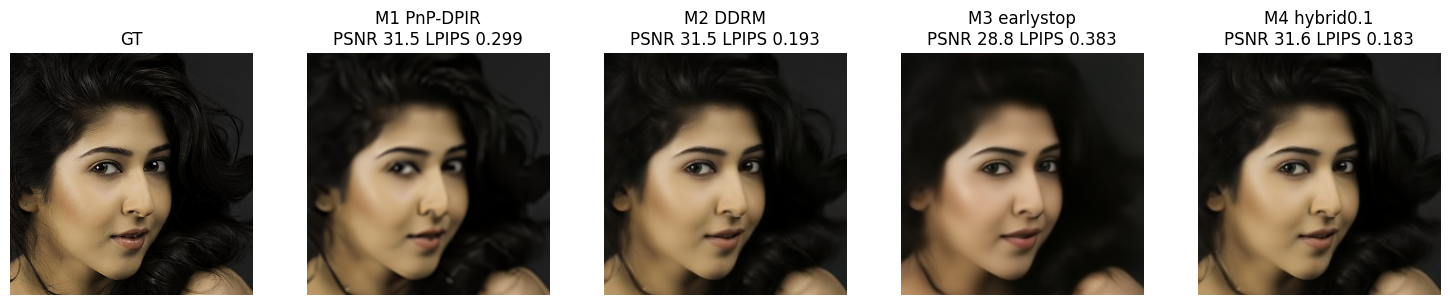

In [11]:
# ====================================================================
# 7. Single-image demo (set the case here)
# ====================================================================
demo_task, demo_dataset = 'sr', 'faces'      # <-- set the demo case: task in {sr,deblur,inpaint}, dataset in {faces,satellite,general}
files=list_images(demo_dataset); assert files, f'no images in images/{demo_dataset}'
gt01=load_img(files[0]); gt=data_transform(gt01); Hf=make_Hfuncs(demo_task)
torch.manual_seed(SEED); y0=Hf.H(gt)+(2*NOISE_STD)*torch.randn_like(Hf.H(gt))
outs={'M1 PnP-DPIR':pnp_dpir(y0,Hf,demo_task),
      'M2 DDRM':ddrm_sample(y0,Hf,sigma_c=0.0,ext=False,seed=SEED),
      'M3 earlystop':ddrm_sample(y0,Hf,t_stop=T_STOP,seed=SEED),
      'M4 hybrid0.1':ddrm_sample(y0,Hf,sigma_c=0.1,ext=True,seed=SEED)}
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,len(outs)+1,figsize=(3*(len(outs)+1),3))
ax[0].imshow(_np(gt01)); ax[0].set_title('GT'); ax[0].axis('off')
for a,(k,v) in zip(ax[1:],outs.items()):
    a.imshow(_np(v)); a.set_title(f'{k}\nPSNR {calc_psnr(v,gt01):.1f} LPIPS {calc_lpips(v,gt01):.3f}'); a.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# ====================================================================
# 8. Run the experiments
# run_matrix() runs every task × domain (~1–2 h). To run a subset, pass lists, e.g.
# run_matrix(tasks=('inpaint',), datasets=('general',)). Scattered inpaint uses INPAINT_MODE='random'.
# ====================================================================
# Full grid (comment out and call subsets if preferred):
run_matrix()
# Examples:
# run_matrix(tasks=('sr',))
# run_matrix(tasks=('inpaint',), datasets=('faces','satellite','general'))

In [ ]:
# ====================================================================
# 9. Aggregate results + figures
# ====================================================================
import pandas as pd
df=pd.read_csv(CSV)
keys=['method','dataset','task'] + (['mask'] if 'mask' in df.columns else [])
summary=df.groupby(keys)[['psnr','ssim','lpips']].mean().round(4)
print(summary); summary.to_csv(os.path.join(RESULTS_DIR,'summary.csv'))

In [ ]:
# LPIPS vs crossover sigma_c, per (task, dataset)
import pandas as pd, matplotlib.pyplot as plt, os
df=pd.read_csv(CSV)
for task in sorted(df.task.unique()):
    sub=df[df.method.str.startswith('M4_hybrid@') & (df.task==task) & (df.method!='M4_hybrid@1000000000.0')].copy()
    if not len(sub): continue
    sub['sigma_c']=sub.method.str.extract(r'@([0-9.]+)').astype(float)
    plt.figure()
    for ds,g in sub.groupby('dataset'):
        gg=g.groupby('sigma_c').lpips.mean(); plt.plot(gg.index, gg.values, marker='o', label=ds)
    plt.xlabel('crossover sigma_c'); plt.ylabel('LPIPS (lower better)'); plt.title(f'{task}: LPIPS vs crossover')
    plt.legend(); plt.grid(True); plt.savefig(os.path.join(RESULTS_DIR,f'lpips_vs_sigmac_{task}.png'),dpi=130,bbox_inches='tight'); plt.show()

In [ ]:
# Qualitative panels for the report (set INPAINT_MODE='box' first for the large-hole figure)
# save_qualitative('faces','inpaint',sigma_c=0.05)
# save_qualitative('general','inpaint',sigma_c=0.5)
# save_qualitative('satellite','sr',sigma_c=0.5)
INPAINT_MODE = 'box'; INPAINT_BOX = 96
save_qualitative('faces', 'inpaint', n=1, sigma_c=0.05)
INPAINT_MODE = 'random'      # reset (irrelevant for SR)
save_qualitative('general', 'sr', n=1, sigma_c=0.2)